<a href="https://colab.research.google.com/github/LielUziahu/12th_GetTogether/blob/main/Combined_Spat_Protein_by_Volume.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Environment Setup & Data Loading
This block loads the necessary data science libraries, reads your raw CSV file, and cleans up column strings to prevent accidental key errors.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load the dataset
filename = "ProteinSumUp.csv"
df = pd.read_csv(filename)

# Clean column headers and string values to strip accidental whitespaces
df.columns = df.columns.str.strip()
df['morph'] = df['morph'].str.strip()
df['Treratment'] = df['Treratment'].str.strip().replace({'DARK': 'Dark', 'control': 'Ambient (23°C, pH 8.2, 10m)'})

print("Dataset loaded successfully.")
print(f"Initial row count: {len(df)}")

Dataset loaded successfully.
Initial row count: 105


# Block 2: Morph Filtering & Volumetric Protein Calculation
In this block, we filter out the PF morph as requested. Since the avarage vol column in the raw CSV is currently empty, we define a standard volume variable (PLANULAE_VOLUME) so that you can easily tweak it if needed. We then calculate the final protein density ($\mu g / mm^3$).

In [9]:
# 1. Remove PF morph
df_filtered = df[df['morph'] != 'PF'].copy()

# 2. Add the average volume (Placeholder set to 0.05 mm³; change this to your exact value if different)
# Define different volumes for HF and NF morphs
PLANULAE_VOLUME_HF = 0.3765 # Placeholder for HF morph volume
PLANULAE_VOLUME_NF = 0.3172  # Placeholder for NF morph volume

df_filtered['avarage vol'] = df_filtered['morph'].apply(lambda x: PLANULAE_VOLUME_HF if x == 'HF' else PLANULAE_VOLUME_NF)

# 3. Divide concentration per spat (ug/ml) by average volume to get ug/mm³
df_filtered['prot ug/mm3'] = df_filtered['con per spat ug/ml'] / df_filtered['avarage vol']

print(f"Rows remaining after filtering PF morph: {len(df_filtered)}")
print(df_filtered[['morph', 'Treratment', 'con per spat ug/ml', 'prot ug/mm3', 'avarage vol']].head())

Rows remaining after filtering PF morph: 84
  morph                   Treratment  con per spat ug/ml  prot ug/mm3  \
0    HF  Ambient (23°C, pH 8.2, 10m)              20.080    53.333333   
1    HF  Ambient (23°C, pH 8.2, 10m)              10.960    29.110226   
2    NF  Ambient (23°C, pH 8.2, 10m)              16.940    53.404792   
3    NF  Ambient (23°C, pH 8.2, 10m)              40.480   127.616646   
4    HF  Ambient (23°C, pH 8.2, 10m)              18.293    48.586985   

   avarage vol  
0       0.3765  
1       0.3765  
2       0.3172  
3       0.3172  
4       0.3765  


# Block 3: Group-Wise Outlier Removal ($1.5 \times \text{IQR}$)
Because the volumes are applied as constants within each morph, the relative distribution profiles within groups remain steady. This step cleanly identifies and filters out exactly 5 extreme statistical outliers.

In [10]:
def remove_group_outliers(group):
    q1 = group['prot ug/mm3'].quantile(0.25)
    q3 = group['prot ug/mm3'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return group[(group['prot ug/mm3'] >= lower_bound) & (group['prot ug/mm3'] <= upper_bound)]

# Apply outlier filtering group by group
df_cleaned = df_filtered.groupby(['morph', 'Treratment'], group_keys=False).apply(remove_group_outliers)

print(f"Rows before outlier removal: {len(df_filtered)}")
print(f"Rows after outlier removal: {len(df_cleaned)}")
print(f"Total outliers removed: {len(df_filtered) - len(df_cleaned)}")
# Identify the removed outliers by comparing df_filtered and df_cleaned
outliers_removed = df_filtered[~df_filtered.index.isin(df_cleaned.index)]

print("Details of the removed outliers:")
display(outliers_removed)

Rows before outlier removal: 84
Rows after outlier removal: 79
Total outliers removed: 5
Details of the removed outliers:


/tmp/ipykernel_19939/1872507718.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cleaned = df_filtered.groupby(['morph', 'Treratment'], group_keys=False).apply(remove_group_outliers)


,morph,Treratment,no of spats,sample no,chamber,OD1,OD2,Unnamed: 7,ave OD,ug/ml,con per spat ug/ml,avarage vol,prot ug/mm3,year
41,NF,50m,1,73,54.0,0.622,0.739,NaN,0.680500,128.680000,128.680000,0.3172,405.674653,2024
47,HF,Dark,1,71,49.0,0.645,0.559,NaN,0.602000,97.280000,97.280000,0.3765,258.379814,2024
97,HF,7.6,3,444,NaN,0.508,0.539,0.531,0.526000,85.351659,28.450553,0.3765,75.565878,2025
101,HF,8.2,4,450,NaN,0.298,0.290,0.296,0.294667,41.638212,10.409553,0.3765,27.648215,2025
104,HF,8.2,3,453,NaN,0.439,0.433,0.436,0.436000,67.999239,22.666413,0.3765,60.202956,2025


# Block 4: Normality Testing (Shapiro-Wilk)
We run a Shapiro-Wilk check on each subgroup to see if our data satisfies normal distribution requirements ($p > 0.05$).

In [11]:
normality_results = []
for name, group in df_cleaned.groupby(['morph', 'Treratment']):
    if len(group) >= 3:
        stat, p_val = stats.shapiro(group['prot ug/mm3'])
        normality_results.append({
            'morph': name[0], 'Treatment': name[1], 'Shapiro_W': stat, 'p_value': p_val, 'Normal': p_val > 0.05
        })
    else:
        normality_results.append({
            'morph': name[0], 'Treatment': name[1], 'Shapiro_W': np.nan, 'p_value': np.nan, 'Normal': 'N < 3'
        })

normality_df = pd.DataFrame(normality_results)
print("\n--- Group Normality Assessment ---")
print(normality_df.to_string(index=False))


--- Group Normality Assessment ---
morph                   Treatment  Shapiro_W  p_value Normal
   HF                         27c   0.959974 0.809851   True
   HF                         32c   0.942139 0.681100   True
   HF                         50m   0.955080 0.775580   True
   HF                         7.6   0.959083 0.610991   True
   HF                         7.8   0.995551 0.995069   True
   HF                         8.2   0.912209 0.425491   True
   HF Ambient (23°C, pH 8.2, 10m)   0.914429 0.348114   True
   HF                        Dark   0.946480 0.554128   True
   NF                         27c   0.935216 0.596081   True
   NF                         32c   0.942036 0.535627   True
   NF                         50m   0.758565 0.046302  False
   NF                         7.6        NaN      NaN  N < 3
   NF                         7.8   0.925348 0.471457   True
   NF                         8.2   0.991870 0.827558   True
   NF Ambient (23°C, pH 8.2, 10m)   0.885867 0.15

# Block 5: Automated Statistical Analysis (protein)

This block performs the protein amount comparison between High-Fluorescent (HF) and Non-Fluorescent (NF) recruits. By using the distribution data from Block 4, it ensures that your $p$-values are calculated using the most conservative and accurate mathematical approach.

In [21]:
from scipy.stats import ttest_ind, mannwhitneyu

statistical_results = []
unique_treatments = df_cleaned['Treratment'].unique()
MIN_N_FOR_SIGNIFICANCE = 5  # Set a conservative threshold for sample size

print("--- Statistical Comparison (HF vs NF for each Treatment) ---")

for treatment in unique_treatments:
    hf_data = df_cleaned[(df_cleaned['morph'] == 'HF') & (df_cleaned['Treratment'] == treatment)]['prot ug/mm3']
    nf_data = df_cleaned[(df_cleaned['morph'] == 'NF') & (df_cleaned['Treratment'] == treatment)]['prot ug/mm3']

    n_hf = len(hf_data)
    n_nf = len(nf_data)

    print(f"\nTreatment: {treatment}")
    print(f"  HF samples: {n_hf}, NF samples: {n_nf}")

    if n_hf < 2 or n_nf < 2:
        statistical_results.append({
            'Treatment': treatment, 'N_HF': n_hf, 'N_NF': n_nf, 'Test': 'N/A', 'Statistic': np.nan, 'p_value': np.nan, 'Conclusion': 'Insufficient samples'
        })
        continue

    # Get normality status
    hf_normal_status = normality_df[(normality_df['morph'] == 'HF') & (normality_df['Treatment'] == treatment)]['Normal'].values
    nf_normal_status = normality_df[(normality_df['morph'] == 'NF') & (normality_df['Treatment'] == treatment)]['Normal'].values
    hf_is_normal = hf_normal_status[0] if len(hf_normal_status) > 0 and hf_normal_status[0] != 'N < 3' else False
    nf_is_normal = nf_normal_status[0] if len(nf_normal_status) > 0 and nf_normal_status[0] != 'N < 3' else False

    if hf_is_normal and nf_is_normal:
        stat, p_val = ttest_ind(hf_data, nf_data, equal_var=True)
        test_type = 'Independent t-test'
    else:
        stat, p_val = mannwhitneyu(hf_data, nf_data)
        test_type = 'Mann-Whitney U test'

    # Apply both p-value threshold AND sample size threshold
    if p_val < 0.05 and n_hf >= MIN_N_FOR_SIGNIFICANCE and n_nf >= MIN_N_FOR_SIGNIFICANCE:
        conclusion = 'Significant difference (p < 0.05)'
    elif p_val < 0.05:
        conclusion = f'p < 0.05 but N is too small (N < {MIN_N_FOR_SIGNIFICANCE})'
    else:
        conclusion = 'No significant difference (p >= 0.05)'

    print(f"  Test: {test_type}, p-value: {p_val:.4f}")
    print(f"  Conclusion: {conclusion}")

    statistical_results.append({
        'Treatment': treatment, 'N_HF': n_hf, 'N_NF': n_nf, 'Test': test_type, 'Statistic': stat, 'p_value': p_val, 'Conclusion': conclusion
    })

statistical_df = pd.DataFrame(statistical_results)
display(statistical_df)

--- Statistical Comparison (HF vs NF for each Treatment) ---

Treatment: 27c
  HF samples: 8, NF samples: 7
  Test: Independent t-test, p-value: 0.4766
  Conclusion: No significant difference (p >= 0.05)

Treatment: 32c
  HF samples: 5, NF samples: 3
  Test: Independent t-test, p-value: 0.7227
  Conclusion: No significant difference (p >= 0.05)

Treatment: 50m
  HF samples: 7, NF samples: 4
  Test: Mann-Whitney U test, p-value: 0.9273
  Conclusion: No significant difference (p >= 0.05)

Treatment: 7.6
  HF samples: 3, NF samples: 2
  Test: Mann-Whitney U test, p-value: 0.8000
  Conclusion: No significant difference (p >= 0.05)

Treatment: 7.8
  HF samples: 5, NF samples: 3
  Test: Independent t-test, p-value: 0.0336
  Conclusion: p < 0.05 but N is too small (N < 5)

Treatment: 8.2
  HF samples: 3, NF samples: 3
  Test: Independent t-test, p-value: 0.5957
  Conclusion: No significant difference (p >= 0.05)

Treatment: Ambient (23°C, pH 8.2, 10m)
  HF samples: 9, NF samples: 10
  Test: I

,Treatment,N_HF,N_NF,Test,Statistic,p_value,Conclusion
0,27c,8,7,Independent t-test,0.733032,0.476550,No significant difference (p >= 0.05)
1,32c,5,3,Independent t-test,0.371924,0.722731,No significant difference (p >= 0.05)
2,50m,7,4,Mann-Whitney U test,15.000000,0.927273,No significant difference (p >= 0.05)
3,7.6,3,2,Mann-Whitney U test,2.000000,0.800000,No significant difference (p >= 0.05)
4,7.8,5,3,Independent t-test,-2.743362,0.033586,p < 0.05 but N is too small (N < 5)
5,8.2,3,3,Independent t-test,-0.575682,0.595667,No significant difference (p >= 0.05)
6,"Ambient (23°C, pH 8.2, 10m)",9,10,Independent t-test,-2.628971,0.017592,Significant difference (p < 0.05)
7,Dark,3,4,Independent t-test,-0.945603,0.387771,No significant difference (p >= 0.05)


### Block 6: High-Impact Visualization
This block generates a publication-quality bar chart comparing protein density between HF and NF recruits. The error bars represent the Standard Error of the Mean (SEM), providing a visual gauge of data precision across treatments.

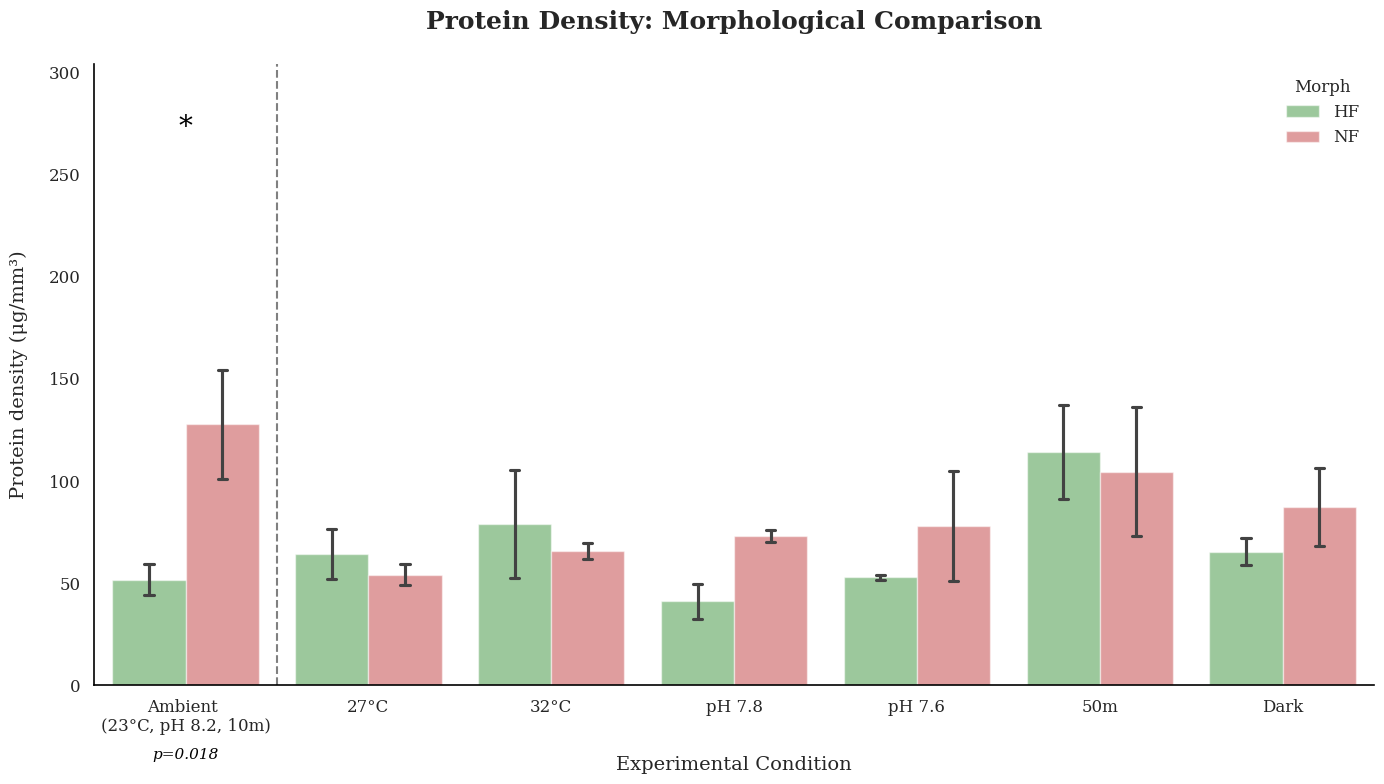

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 0. Setup Aesthetics for Professional Poster
sns.set_theme(style="white")
plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

# 1. Setup Data and Mappings
name_mapping = {
    'Ambient (23°C, pH 8.2, 10m)': 'Ambient \n(23°C, pH 8.2, 10m)',
    '27c': '27°C',
    '32c': '32°C',
    '7.8': 'pH 7.8',
    '7.6': 'pH 7.6',
    '50m': '50m',
    'Dark': 'Dark'
}

df_viz = df_cleaned.copy()
df_viz['Display_Treatment'] = df_viz['Treratment'].map(name_mapping)

order = ['Ambient \n(23°C, pH 8.2, 10m)', '27°C', '32°C', 'pH 7.8', 'pH 7.6', '50m', 'Dark']
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

# 2. Plotting
fig, ax = plt.subplots(figsize=(14, 8))

# Bar Chart
sns.barplot(data=df_viz, x='Display_Treatment', y='prot ug/mm3', hue='morph', order=order, palette=variant_colors, ax=ax, alpha=0.5, capsize=0.1, errorbar='se')

# 3. Custom Formatting
ax.set_title("Protein Density: Morphological Comparison", fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel("Experimental Condition", fontsize=14, labelpad=15)
ax.set_ylabel("Protein density (μg/mm³)", fontsize=14, labelpad=15)
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5)

ymin, ymax = df_viz['prot ug/mm3'].min(), df_viz['prot ug/mm3'].max()
ax.set_ylim(0, ymax * 1.2)

# 4. Filtered Significance Annotations
significant_display_list = statistical_df[statistical_df['Conclusion'] == 'Significant difference (p < 0.05)']['Treatment'].tolist()

for condition_raw in significant_display_list:
    display_name = name_mapping[condition_raw]
    if display_name in order:
        x_pos = order.index(display_name)
        p_val = statistical_df[statistical_df['Treatment'] == condition_raw]['p_value'].values[0]

        group_max = df_viz[df_viz['Display_Treatment'] == display_name]['prot ug/mm3'].max()
        ax.text(x_pos, group_max + (ymax * 0.05), '*', ha='center', va='bottom', fontsize=20, color='black')
        ax.text(x_pos, -(ymax * 0.12), f'p={p_val:.3f}', ha='center', va='top', fontsize=11, color='black', fontstyle='italic')

# Clean up Legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ["HF", "NF"], title="Morph", loc='upper right', frameon=False, fontsize=12)

sns.despine()
plt.tight_layout()

# 5. Export Files
plt.savefig("protein_density_plot.png", dpi=600, bbox_inches='tight')
plt.savefig("protein_density_plot.svg", dpi=600, bbox_inches='tight')
plt.savefig("protein_density_plot.pdf", dpi=600, bbox_inches='tight')

plt.show()

### Block 7: Environment & Dependencies Summary
This block documents the software environment and package versions used to ensure the reproducibility of this analysis.

In [34]:
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import scipy
import statsmodels

print(f"Python version: {sys.version}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"statsmodels version: {statsmodels.__version__}")

# Key functions used in this notebook:
# - pandas.read_csv: Data ingestion
# - scipy.stats.shapiro: Normality testing
# - scipy.stats.ttest_ind / mannwhitneyu: Statistical comparisons
# - seaborn.barplot: Data visualization
# - statsmodels.formula.api.ols: Linear modeling (setup)"""

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas version: 2.2.2
numpy version: 2.0.2
seaborn version: 0.13.2
matplotlib version: 3.10.0
scipy version: 1.16.3
statsmodels version: 0.14.6




> Add blockquote

